# Library Imports

In [1]:
import torch
import random
import copy

import numpy as np
import matplotlib.pyplot as plt

import micrograd.nn as nn
from micrograd.engine import Value
import micrograd

# Implement Forward Pass and Back-Propagation in Pytorch

Simple neuron with 2 nodes and 2 weights and a bias, and then passed through tanh() activation function. tanh() is usualy represented as the exponential. 

$ x_1 = 2, x_2 = 0, w_1 = -3, w_2 = 1, b = 6.88137 $

$ n = x_1w_1 + x_2w_2 + b  \\ $
$ f = e^{2n} \\ $
$ o = \frac{e-1}{e+1} $

1. Why the recast to double? Torch uses float32 precision and python uses double precision. Hence to make things uniform. 
2. Torch doesn't compute gradients for leaf nodes, but we do want them, hence set requires_grad == True 

In [2]:
x1 = torch.Tensor([2.0]).double()       ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()       ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()      ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()       ; w2.requires_grad = True
b = torch.Tensor([6.88137]).double()    ; b.requires_grad = True

# do forward pass
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)
print("Value of o: ", o.data.item())

# backpropagate
o.backward()

# print gradients of everything
print("Gradient of x1: ", x1.grad.item())
print("Gradient of w1: ", w1.grad.item())
print("Gradient of x2: ", x2.grad.item())
print("Gradient of w2: ", w2.grad.item())
print("Gradient of b: ", b.grad.item())

Value of o:  0.7071050214706146
Gradient of x1:  -1.500007465833125
Gradient of w1:  1.0000049772220834
Gradient of x2:  0.5000024886110417
Gradient of w2:  0.0
Gradient of b:  0.5000024886110417


## Let's design a Neuron

In [3]:
def tanhValue(inp: Value):

    """ Implement a tanH function for the micrograd values data type """

    inpData = torch.Tensor([inp.data]).double()
    return Value(torch.tanh(inpData).item())

def sineValue(inp: Value):

    """ Implement a sine function for micrograd values data type """

    inpData = inp.data
    return Value(np.sin(inpData))

In [4]:
class Neuron:

    """ Takes n_inputs and gives back 1 output """

    def __init__(self, n_inputs):
        
        self.n_inputs = n_inputs
        self.weights = [Value(random.uniform(-1, 1)) for _ in range(n_inputs)]
        self.bias = Value(random.uniform(-1, 1))

    def __call__(self, x):


        # check if the lengths of inputs and desired length matches    
        assert(len(x) == self.n_inputs)

        # compute w*x + b: like a neuron function 
        action = sum(((w_i*x_i) for w_i, x_i in zip(self.weights, x)), self.bias)

        # pass through non-linear activation function
        outputN = tanhValue(action)

        return outputN

    def parameters(self):
        return self.weights + [self.bias]

class Layer:

    """ an array of n_outputs neurons, with each taking n_inputs inputs """

    # define an array of neurons
    def __init__(self, n_inputs: int, n_outputs: int):
        self.neurons = [Neuron(n_inputs) for _ in range(n_outputs)]

    # pass the input through each neuron and then collate the output
    def __call__(self, x):
        outputL = [n(x) for n in self.neurons]
        return outputL[0] if len(outputL)==1 else outputL

    def parameters(self):
        Layparams = []
        for neuron in self.neurons:
            neuParams = neuron.parameters()
            Layparams.extend(neuParams)

        return Layparams

class MLP:

    """
    Multiple layers now: in one layer we only told how many neurons we want in layer
    here we will give a list of sizes, and the number of layers will be inferred from the size of the list
    """

    # a layer's inputs are same size as preceding layers outouts
    def __init__(self, n_inputs: int, n_outputs: list):
        sizes = [n_inputs] + n_outputs
        self.layers = [Layer(sizes[i], sizes[i+1]) for i in range(len(n_outputs))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x    

    def parameters(self):
        mlpParams = []
        for layer in self.layers:
            Layparams = layer.parameters()
            mlpParams.extend(Layparams)
        return mlpParams

# Train a NN to fit a function: $x^2$

## Gradient Descent Algorithms

In [5]:
def SGD(p: micrograd.engine.Value, 
        lr: float):

    return lr * p.grad

def momentum(v: float, 
             p: micrograd.engine.Value, 
             beta: float):

    # beta is like a remembering factor, to ensure finiteness, beta must be less than 1.0
    assert beta < 1.0
    v1 = beta*v + p.grad # proxy for gradient, history/accumulation of gradients, with latest gra
    return v1

def rmsprop(s: float, 
            p: micrograd.engine.Value, 
            beta: float) -> float:

    assert beta < 1.0
    s1 = beta * s + (1-beta)*(p.grad**2)
    return s1

def adam(v_adam: float, 
         s_adam: float, 
         p: micrograd.engine.Value, 
         beta1: float, 
         beta2: float, 
         epoch_num: int) -> tuple[float, float, float, float]:

    assert beta1 < 1.0 and beta2 < 1.0

    v1_adam = beta1*v_adam + (1-beta1)*p.grad
    s1_adam = beta2*s_adam + (1-beta2)*p.grad**2

    # bias correction: (initial velocities and squared gradients are squared towards 0)
    v1_adam_hat = v1_adam/(1- beta1**(epoch_num+1))
    s1_adam_hat = s1_adam/(1 - beta2**(epoch_num+1))

    return v1_adam, s1_adam, v1_adam_hat, s1_adam_hat

In [6]:
def simple_train(x_train: list,
                 y_train: list,
                 x_val: list,
                 y_val: list,
                 MLP1: micrograd.nn.MLP, 
                 lr: float = 0.005, 
                 beta: float = 0.9, 
                 epochs: int = 3000, 
                 epsilon: float = 1e-10, 
                 beta1: float = 0.9, 
                 beta2: float = 0.999, 
                 algo: str = "grad"
                 ) -> tuple[np.array[float], micrograd.nn.MLP]:

    """
    MLP: Neural Net
    lr: learning rate
    beta: decay rate for momentum
    epochs: number of epochs to train for
    epsilon: small positive value
    beta1: decay rate for momentum for adam
    beta2: decay rate for squared gradients for adam
    algo: algorithm to train with, "grad", "momentum", "rmsprop", and "adam"
    """

    # define loss store:
    loss_store = np.zeros(epochs)
    val_loss_store = np.zeros(epochs)

    # define velocity and squared gradients
    v = {p: 0.0 for p in MLP1.parameters()}
    s = {p: 0.0 for p in MLP1.parameters()}

    for epoch in range(epochs):

        # Forward pass
        y_pred = [MLP1([x]) for x in x_train]

        # MSE loss
        loss = sum((yp - yt)**2 for yp, yt in zip(y_pred, y_train)) / len(y_train)

        # Zero gradients
        for p in MLP1.parameters():
            p.grad = 0.0

        # do backward pass
        loss.backward()

        # Gradient descent
        for p in MLP1.parameters():
            if algo=="grad":
                p.data -= SGD(p, lr) #lr * p.grad # Stochastic Gradient Descent
            elif algo=="momentum":
                v[p] = momentum(v[p], p, beta)
                p.data -= lr*v[p]
            elif algo=="rmsprop":
                s[p] = rmsprop(s[p], p, beta)
                p.data -= (lr/(np.sqrt(s[p]) + epsilon))*p.grad
            elif algo=="adam":
                v[p], s[p], v_hat, s_hat = adam(v[p], s[p], p, beta1, beta2, epoch)
                p.data -= lr*v_hat/(np.sqrt(s_hat) + epsilon)
            else:
                raise ValueError(f"Unknown algorithm: {algo}")

        # store training loss
        loss_store[epoch] = loss.data

        # store validation loss
        y_val_pred = [MLP1([x]) for x in x_val]
        val_loss = sum((yp - yt)**2 for yp, yt in zip(y_val_pred, y_val)) / len(y_val)
        val_loss_store[epoch] = val_loss.data


    return [loss_store, val_loss_store, MLP1]

In [7]:
def generate_data(x_raw: np.array, 
                  y_raw: np.array, 
                  train: float, 
                  val: float, 
                  test: float) -> tuple(tuple(np.array, np.array), tuple(np.array, np.array), tuple(np.array, np.array)):

    """ write a custom function to generate training data """

    assert train + val + test == 1.0

    n = len(x_raw)

    # create randomized indexes
    idxs = np.random.permutation(n)

    # compute indexes
    tr_idx = int(n*train)
    tr_idxs = idxs[:tr_idx]
    ts_idx = int(n*test)
    ts_idxs = idxs[tr_idx: tr_idx+ts_idx]
    vl_idxs = idxs[tr_idx+ts_idx:]

    x_train, y_train = x_raw[tr_idxs], y_raw[tr_idxs]
    x_test, y_test = x_raw[ts_idxs], y_raw[ts_idxs]
    x_val, y_val = x_raw[vl_idxs], y_raw[vl_idxs]

    x_train = [Value(each) for each in x_train]
    y_train = [Value(each) for each in y_train] #[(x_tr)**2 for x_tr in x_train]

    x_val = [Value(each) for each in x_val]
    y_val = [Value(each) for each in y_val]

    x_test = [Value(each) for each in x_test]
    y_test = [Value(each) for each in y_test]

    print(len(x_train), len(x_val), len(x_test))

    return (x_train, y_train), (x_test, y_test), (x_val, y_val)

# 1. Create training and testing data

# keep repeatable
np.random.seed(42)

x_raw = np.random.uniform(-2, 2, 60)
y_raw = np.array([x**2 for x in x_raw])

(x_train, y_train), (x_test, y_test), (x_val, y_val) = generate_data(x_raw, y_raw, train=0.6, test=0.2, val=0.2)

# 2. Create base model architecture
base_mlp = nn.MLP(1, [4, 4, 1])
algorithms = ["grad"]#, "momentum", "rmsprop", "adam"]

# 3 Create storage for loss and trained nets
results, val_results, MLPS = {}, {}, []

# 4 Train
for algo in algorithms:
    # Deep copy network so every algorithm starts from identical weight initialization
    mlp_copy = copy.deepcopy(base_mlp)
    
    # Train using simple_train
    loss_history, val_loss_history, trained_mlp = simple_train(
        x_train=x_train, 
        y_train=y_train, 
        x_val=x_val,
        y_val=y_val,
        MLP1=mlp_copy, 
        lr=0.005, 
        epochs=5000, 
        algo=algo
    )

    results[algo] = loss_history
    val_results[algo] = val_loss_history
    MLPS.append(mlp_copy)

36 12 12


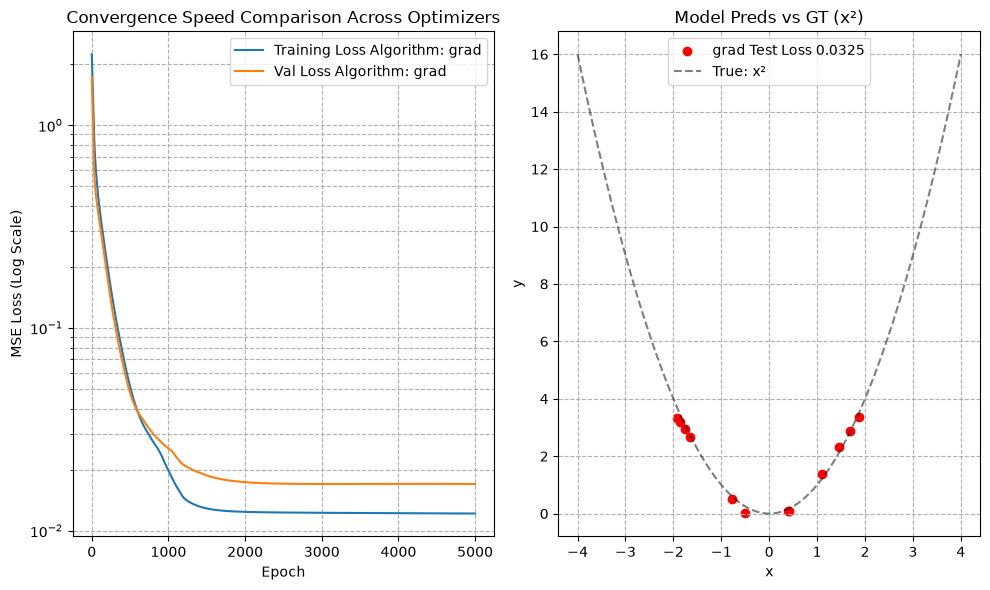

In [ ]:
# 5 Inference
y_preds = []
for i in range(len(MLPS)):
    y_pred = [MLPS[i]([x_ts]) for x_ts in x_test]
    y_preds.append(y_pred)

    
# 6. Plot comparative loss curves
fig, axs = plt.subplots(1, 2, figsize=(10, 6))
for algo, loss_hist in results.items():
    axs[0].plot(loss_hist, label=f"Training Loss Algorithm: {algo}")
for algo, loss_hist in val_results.items():
    axs[0].plot(loss_hist, label=f"Val Loss Algorithm: {algo}")

axs[0].set_yscale('log')  # Log scale makes convergence differences much easier to see
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("MSE Loss (Log Scale)")
axs[0].set_title("Convergence Speed Comparison Across Optimizers")
axs[0].legend()
axs[0].grid(True, which="both", ls="--")

colors = ['r', 'b', 'g', 'm']
test_loss = []
x_test_numeric = [float(x.data) for x in x_test]
for i, algo in enumerate(algorithms):
    y_test_numeric = [float(each.data) for each in y_preds[i]]
    test_loss.append(sum((float(yp.data) - float(yt.data))**2 for yp, yt in zip(y_preds[i], y_test)) / len(y_test))
    axs[1].scatter(x_test_numeric, y_test_numeric, color=colors[i], label=f"{algo} Test Loss {np.round(test_loss[i].data, 4)}")

axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
axs[1].set_title("Model Preds vs GT (x²)")
axs[1].legend()
axs[1].grid(True, ls="--")

# Optional: plot true function for reference
x_true = np.linspace(-4, 4, 100)
axs[1].plot(x_true, x_true**2, 'k--', alpha=0.5, label="True: x²")
axs[1].legend()

plt.tight_layout()
plt.show()